<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/Gps_scenario_2_2_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== ERROR METRICS =====

Mean Horizontal Error: 7.5095 m
Mean Bias Vector [mu_x, mu_y]: [1.1603, -7.0649] m
Mean Bias Magnitude (P_F): 7.1595 m
Variance of Horizontal Error: 5.7746 m²
Trace of Covariance Matrix: 11.3033 m²
RMS Horizontal Error: 7.8584 m
CEP50: 7.3356 m


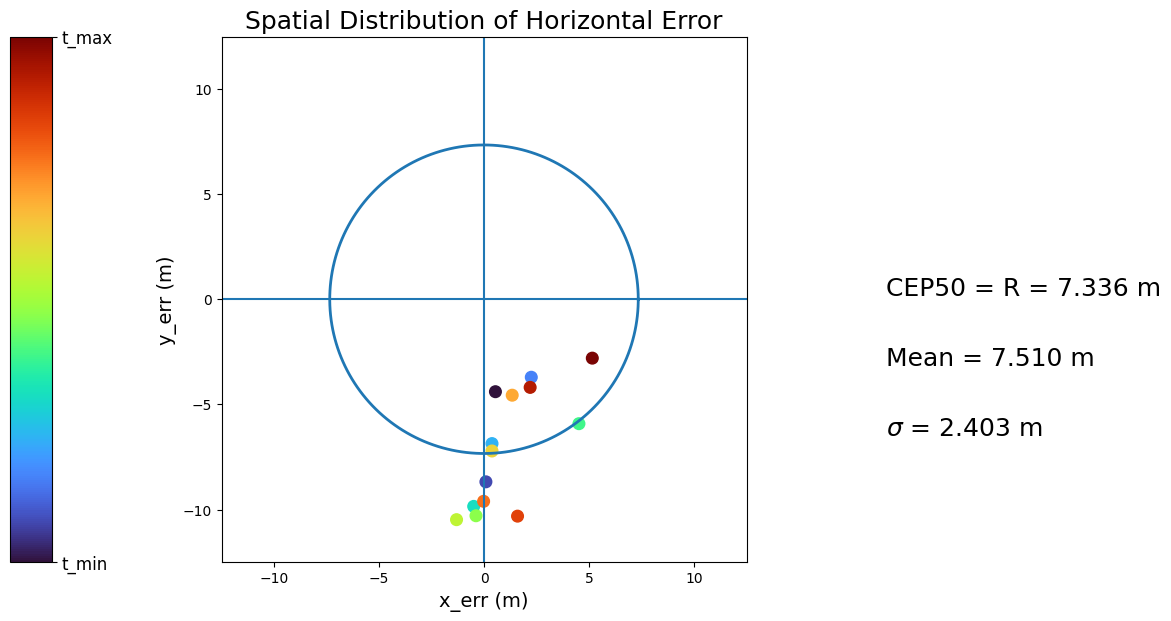

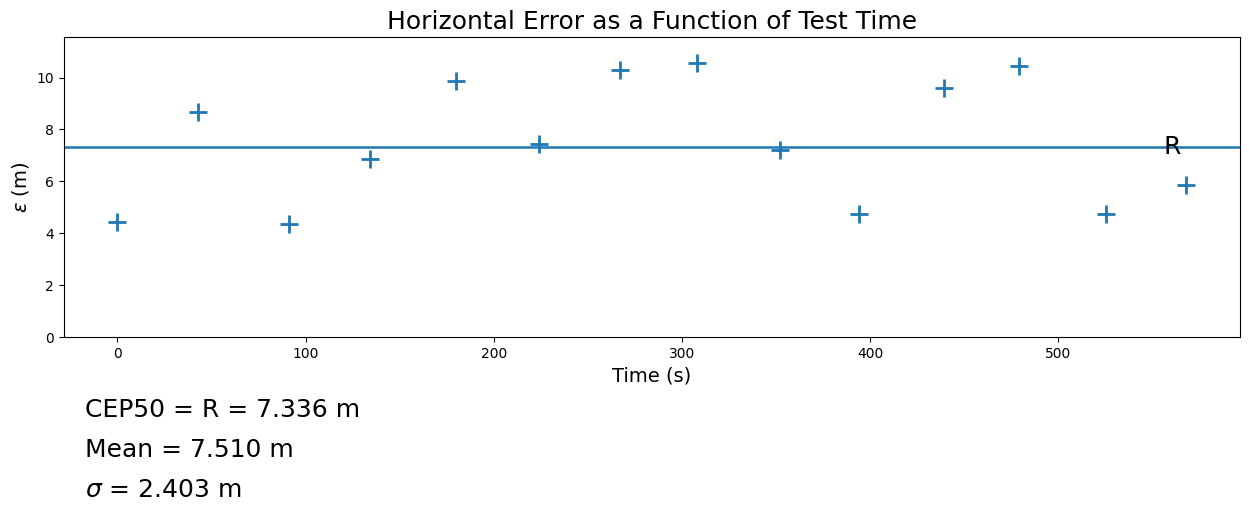


Generated files:
/content/error_table_EC_EBP.csv
/content/gps_metrics_summary.csv


In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos


# ==========================================
# LOAD CSV FILE
# ==========================================

# Upload this file to Colab:
# gps_scenario2_2.csv

file_path = "/content/sample_data/gps_scenario2_2.csv"

df = pd.read_csv(file_path)


# ==========================================
# DATA CLEANING
# ==========================================

# Remove extra spaces from column names
df.columns = [c.strip() for c in df.columns]


# ==========================================
# NUMERIC CONVERSION
# ==========================================

for col in [

    "Latitud EC",
    "Longitud EC",

    "Latitud EBP",
    "Longitud EBP"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ==========================================
# TIME CONVERSION
# ==========================================

df["Hora_dt"] = pd.to_datetime(
    df["Hora"],
    format="%H:%M:%S",
    errors="coerce"
)


# ==========================================
# REMOVE INVALID DATA
# ==========================================

df = df.dropna(
    subset=[
        "Hora_dt",

        "Latitud EC",
        "Longitud EC",

        "Latitud EBP",
        "Longitud EBP"
    ]
).copy()

df = df.sort_values(
    "Hora_dt"
).reset_index(drop=True)


# ==========================================
# RELATIVE TIME
# ==========================================

df["t_s"] = (
    df["Hora_dt"] - df["Hora_dt"].iloc[0]
).dt.total_seconds()


# ==========================================
# DEGREE TO METER CONVERSION
# ==========================================

lat_mean = pd.concat([
    df["Latitud EC"],
    df["Latitud EBP"]
]).mean()

meters_per_deg_lat = 111320

meters_per_deg_lon = (
    111320 *
    cos(radians(lat_mean))
)


# ==========================================
# POSITION ERROR CALCULATION
# ==========================================

df["x_err_m"] = (
    (df["Longitud EC"] - df["Longitud EBP"])
    * meters_per_deg_lon
)

df["y_err_m"] = (
    (df["Latitud EC"] - df["Latitud EBP"])
    * meters_per_deg_lat
)

df["error_total_m"] = np.sqrt(
    df["x_err_m"]**2 +
    df["y_err_m"]**2
)


# ==========================================
# METRICS
# ==========================================

mean_e = df["error_total_m"].mean()

mu_x = df["x_err_m"].mean()

mu_y = df["y_err_m"].mean()

pf = np.sqrt(
    mu_x**2 +
    mu_y**2
)

var_eh = df["error_total_m"].var(ddof=1)

sigma = np.sqrt(var_eh)

cov_matrix = np.cov(
    df["x_err_m"],
    df["y_err_m"],
    ddof=1
)

trace_cov = np.trace(cov_matrix)

rms = np.sqrt(
    np.mean(df["error_total_m"]**2)
)

cep50 = np.percentile(
    df["error_total_m"],
    50
)


# ==========================================
# PRINT METRICS
# ==========================================

print("\n===== ERROR METRICS =====\n")

print(
    f"Mean Horizontal Error: "
    f"{mean_e:.4f} m"
)

print(
    f"Mean Bias Vector [mu_x, mu_y]: "
    f"[{mu_x:.4f}, {mu_y:.4f}] m"
)

print(
    f"Mean Bias Magnitude (P_F): "
    f"{pf:.4f} m"
)

print(
    f"Variance of Horizontal Error: "
    f"{var_eh:.4f} m²"
)

print(
    f"Trace of Covariance Matrix: "
    f"{trace_cov:.4f} m²"
)

print(
    f"RMS Horizontal Error: "
    f"{rms:.4f} m"
)

print(
    f"CEP50: "
    f"{cep50:.4f} m"
)


# ==========================================
# FIGURE 1
# SPATIAL ERROR DISTRIBUTION
# ==========================================

fig = plt.figure(figsize=(12, 7))

ax = fig.add_axes([
    0.18,
    0.14,
    0.55,
    0.75
])


# Scatter plot
sc = ax.scatter(
    df["x_err_m"],
    df["y_err_m"],
    c=df["t_s"],
    cmap="turbo",
    s=70
)


# Central axes
ax.axhline(0, linewidth=1.5)

ax.axvline(0, linewidth=1.5)


# CEP50 circle
theta = np.linspace(
    0,
    2*np.pi,
    400
)

ax.plot(
    cep50 * np.cos(theta),
    cep50 * np.sin(theta),
    linewidth=2.0
)


# Plot limits
max_lim = max(

    np.max(np.abs(df["x_err_m"])),

    np.max(np.abs(df["y_err_m"])),

    cep50

) + 2

ax.set_xlim(-max_lim, max_lim)

ax.set_ylim(-max_lim, max_lim)

ax.set_aspect(
    "equal",
    adjustable="box"
)


# Labels
ax.set_xlabel(
    "x_err (m)",
    fontsize=14
)

ax.set_ylabel(
    "y_err (m)",
    fontsize=14
)

ax.set_title(
    "Spatial Distribution of Horizontal Error",
    fontsize=18
)


# ==========================================
# COLORBAR
# ==========================================

cax = fig.add_axes([
    0.06,
    0.14,
    0.035,
    0.75
])

cb = plt.colorbar(
    sc,
    cax=cax
)

cb.set_ticks([
    df["t_s"].min(),
    df["t_s"].max()
])

cb.set_ticklabels([
    "t_min",
    "t_max"
])

cb.ax.tick_params(labelsize=12)


# ==========================================
# METRICS TEXT
# ==========================================

fig.text(
    0.79,
    0.52,
    f"CEP50 = R = {cep50:.3f} m",
    fontsize=18
)

fig.text(
    0.79,
    0.42,
    f"Mean = {mean_e:.3f} m",
    fontsize=18
)

fig.text(
    0.79,
    0.32,
    r"$\sigma$" + f" = {sigma:.3f} m",
    fontsize=18
)

plt.show()


# ==========================================
# FIGURE 2
# HORIZONTAL ERROR VS TIME
# ==========================================

fig2 = plt.figure(figsize=(14, 5))

ax2 = fig2.add_axes([
    0.08,
    0.26,
    0.84,
    0.60
])


# Scatter plot
ax2.scatter(
    df["t_s"],
    df["error_total_m"],
    marker="+",
    s=180,
    linewidths=2
)


# CEP50 reference line
ax2.axhline(
    cep50,
    linewidth=1.8
)

ax2.text(
    df["t_s"].max() * 0.995,
    cep50,
    "R",
    ha="right",
    va="center",
    fontsize=18
)


# Labels
ax2.set_xlabel(
    "Time (s)",
    fontsize=14
)

ax2.set_ylabel(
    r"$\epsilon$ (m)",
    fontsize=14
)

ax2.set_title(
    "Horizontal Error as a Function of Test Time",
    fontsize=18
)


# Axis limits
ymax = max(
    df["error_total_m"].max(),
    cep50
) + 1

ax2.set_ylim(0, ymax)


# Metrics text
fig2.text(
    0.095,
    0.10,
    f"CEP50 = R = {cep50:.3f} m",
    fontsize=18
)

fig2.text(
    0.095,
    0.02,
    f"Mean = {mean_e:.3f} m",
    fontsize=18
)

fig2.text(
    0.095,
    -0.06,
    r"$\sigma$" + f" = {sigma:.3f} m",
    fontsize=18
)

plt.show()


# ==========================================
# EXPORT RESULTS
# ==========================================

results_table = df[[

    "Hora",

    "Latitud EC",
    "Longitud EC",

    "Latitud EBP",
    "Longitud EBP",

    "x_err_m",
    "y_err_m",
    "error_total_m"

]].copy()


# Export error table
results_table.to_csv(
    "/content/error_table_EC_EBP.csv",
    index=False
)


# ==========================================
# EXPORT METRICS SUMMARY
# ==========================================

summary = pd.DataFrame({

    "Metric": [

        "Mean Horizontal Error",

        "Mean Bias Vector mu_x",

        "Mean Bias Vector mu_y",

        "Mean Bias Magnitude (P_F)",

        "Variance of Horizontal Error",

        "Trace of Covariance Matrix",

        "RMS Horizontal Error",

        "CEP50"
    ],

    "Value": [

        mean_e,

        mu_x,

        mu_y,

        pf,

        var_eh,

        trace_cov,

        rms,

        cep50
    ]
})


summary.to_csv(
    "/content/gps_metrics_summary.csv",
    index=False
)


# ==========================================
# GENERATED FILES
# ==========================================

print("\nGenerated files:")

print("/content/error_table_EC_EBP.csv")

print("/content/gps_metrics_summary.csv")